## EDA y Feature Engineering

In [14]:
# Importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Primero, cargamos el archivo original que contiene las etiquetas originales de cada imagen y luego, 
visualizamos las primeras filas para entender la estructura base de este archivo.

In [15]:
df = pd.read_csv('./imagenes/ground_truth.csv')
display(df.head(15))

,filename,tom,jerry
0,frame0.jpg,0,0
1,frame1.jpg,0,0
2,frame2.jpg,0,0
3,frame3.jpg,0,0
4,frame4.jpg,0,0
5,frame5.jpg,0,0
6,frame6.jpg,0,0
7,frame7.jpg,0,0
8,frame8.jpg,0,0
9,frame9.jpg,0,0


Como se puede apreciar en el dataframe, este utiliza un formato binario para clasificar las imágenes en base 
a la presencia (1) o ausencia (0) de cada personaje por separado.

Para poder visualizar la distribución de las clases y ajustar el dataframe a la estructura de 4 carpetas que 
leerá el modelo a entrenar (`tom`, `jerry`, `tom_jerry_1`, `tom_jerry_0`), se crea una función que lea ambas 
columnas binarias y asigne a cada fila una categoría única en texto.

In [16]:
# crear una nueva columna que represente el nombre de las 4 carpetas
def asignar_clase(fila):
    if fila['tom'] == 1 and fila['jerry'] == 0:
        return 'tom'
    elif fila['tom'] == 0 and fila['jerry'] == 1:
        return 'jerry'
    elif fila['tom'] == 1 and fila['jerry'] == 1:
        return 'tom_jerry_1'
    else:
        return 'tom_jerry_0'

In [17]:
# aplicar la funcion al dataframe
df['categoria'] = df.apply(asignar_clase, axis=1)

In [18]:
# ver como quedo el dataframe luego de agregar la columna nueva
display(df.head(15))

,filename,tom,jerry,categoria
0,frame0.jpg,0,0,tom_jerry_0
1,frame1.jpg,0,0,tom_jerry_0
2,frame2.jpg,0,0,tom_jerry_0
3,frame3.jpg,0,0,tom_jerry_0
4,frame4.jpg,0,0,tom_jerry_0
5,frame5.jpg,0,0,tom_jerry_0
6,frame6.jpg,0,0,tom_jerry_0
7,frame7.jpg,0,0,tom_jerry_0
8,frame8.jpg,0,0,tom_jerry_0
9,frame9.jpg,0,0,tom_jerry_0


Graficar la distribución de las clases para ver si está balanceado el dataset.

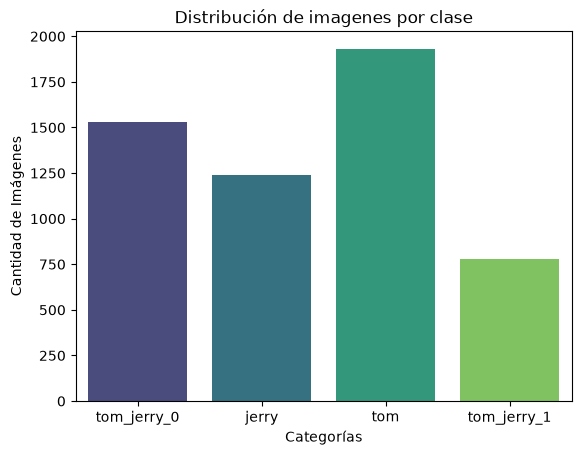

In [19]:
#plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='categoria', hue='categoria', palette='viridis')
plt.title('Distribución de imagenes por clase')
plt.xlabel('Categorías')
plt.ylabel('Cantidad de Imágenes')
plt.savefig("distribucion_clases.png")
plt.show()

A continuación, se realizará un análisis de las dimensiones de las imágenes, ya que para que ResNet50 pueda 
procesarlas se requiere que tengan un dimensionamiento exacto.

In [20]:
import os
from PIL import Image

In [21]:
dir_imagenes = './imagenes'
clases = ['tom', 'jerry', 'tom_jerry_1', 'tom_jerry_0']

anchos = []
altos = []

In [22]:
for c in clases:
    ruta_clase = os.path.join(dir_imagenes, c)
    for imagen_nombre in os.listdir(ruta_clase):
        imagen_path = os.path.join(ruta_clase, imagen_nombre)
        with Image.open(imagen_path) as img:
            ancho, alto = img.size
            anchos.append(ancho)
            altos.append(alto)

In [23]:
dimensiones = pd.DataFrame({'Ancho': anchos, 'Alto': altos})

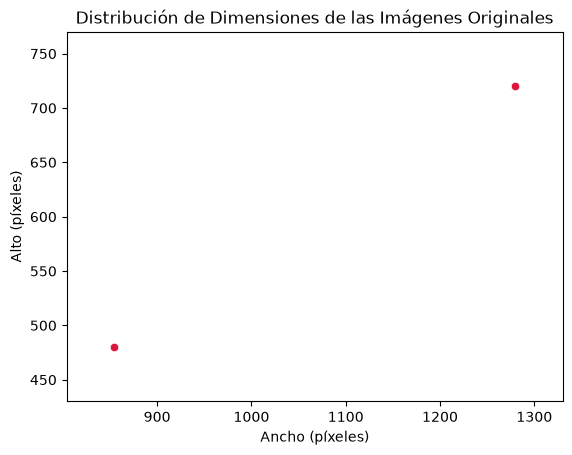

In [24]:
sns.scatterplot(data=dimensiones, x='Ancho', y='Alto', color='crimson')

plt.xlim(dimensiones['Ancho'].min()-50, dimensiones['Ancho'].max()+50)
plt.ylim(dimensiones['Alto'].min()-50, dimensiones['Alto'].max()+50)

plt.title('Distribución de Dimensiones de las Imágenes Originales')
plt.xlabel('Ancho (píxeles)')
plt.ylabel('Alto (píxeles)')
plt.savefig("grafico_dimensiones.png")
plt.show()

### Ejemplos visuales por clase

Antes de entrenar, revisamos una imagen de ejemplo por cada categoría para detectar a simple vista posibles 
problemas de etiquetado.

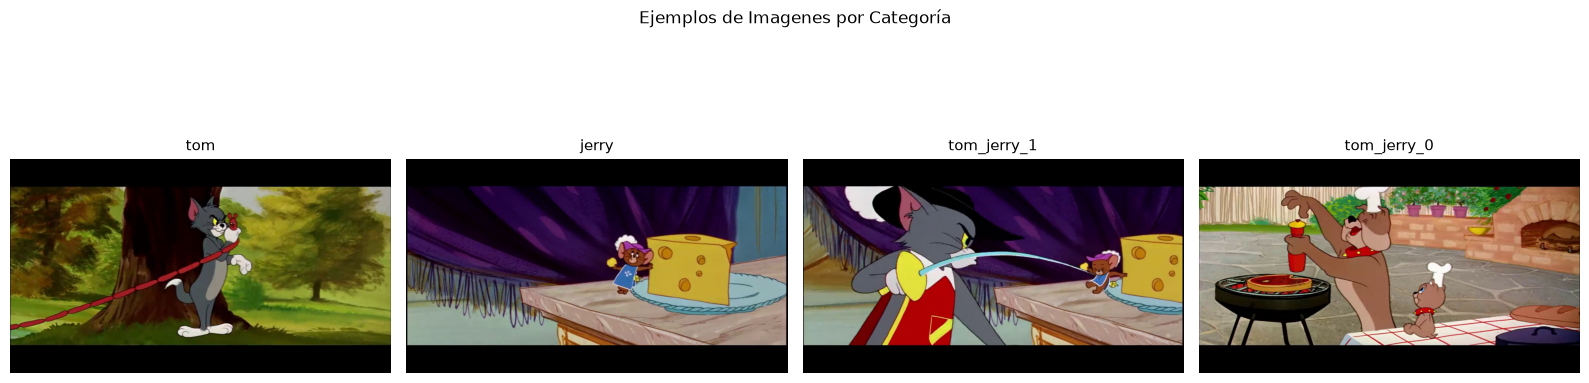

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, c in zip(axes, clases):
    ruta_clase = os.path.join(dir_imagenes, c)
    imagen_nombre = os.listdir(ruta_clase)[0]
    img = Image.open(os.path.join(ruta_clase, imagen_nombre))
    ax.imshow(img)
    ax.set_title(c, fontsize=11)
    ax.axis('off')

plt.suptitle('Ejemplos de Imagenes por Categoría')
plt.tight_layout()
plt.show()

### Preparación de las imágenes

In [26]:
import numpy as np
import torch
from torchvision import transforms                      # para transformaciones y estandarizacion
from torchvision.datasets import ImageFolder            # para etiquetar cada imagen
from torch.utils.data import DataLoader, Subset         # entrenamiento y division de datos
import torch.optim as optim
from sklearn.metrics import classification_report

In [27]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3050 Laptop GPU'

In [28]:
torch.cuda.is_available()

True

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [30]:
# transformaciones para Training
transformaciones_train = transforms.Compose([
    transforms.Resize((256, 256)),                  # estandarizar el tamaño de las imagenes a 256 x 256px
    transforms.RandomHorizontalFlip(p=0.5),         # invierte la imagen horizontalmente, para control de overfitting
    transforms.RandomRotation(degrees=15),          # rota la imagen en 15° para evitar overfitting
    transforms.CenterCrop(224),                     # recorta las imagenes en un cuadrado de 224 x 224px
    transforms.ToTensor(),                          # convierta la imagen a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# transformaciones para Validation y Test
transformaciones_eval = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [31]:
# cargamos el dataset dos veces, una con cada transformacion, apuntando a la misma carpeta
dataset_train_full = ImageFolder('./imagenes', transform=transformaciones_train)
dataset_eval_full = ImageFolder('./imagenes', transform=transformaciones_eval)

n_total = len(dataset_train_full)
entrenamiento_tam = int(0.70 * n_total)
validacion_tam = int(0.15 * n_total)
test_tam = n_total - entrenamiento_tam - validacion_tam

generador = torch.Generator().manual_seed(1)

indices = torch.randperm(n_total, generator=generador).tolist()
train_indices = indices[:entrenamiento_tam]
val_indices = indices[entrenamiento_tam:entrenamiento_tam + validacion_tam]
test_indices = indices[entrenamiento_tam + validacion_tam:]

train_dataset = Subset(dataset_train_full, train_indices)
val_dataset = Subset(dataset_eval_full, val_indices)
test_dataset = Subset(dataset_eval_full, test_indices)

In [32]:
# crea dataloaders para que el modelo lea en paquetes de 32 imagenes
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# mensajes de confirmacion
print(f"clases detectadas automaticamente: {dataset_train_full.classes}")
print(f"total de imagenes para entrenamiento: {len(train_dataset)}")
print(f"total de imagenes para validacion: {len(val_dataset)}")
print(f"total de imagenes para test: {len(test_dataset)}")

clases detectadas automaticamente: ['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']
total de imagenes para entrenamiento: 3834
total de imagenes para validacion: 821
total de imagenes para test: 823


Al observar la distribución de clases graficada al inicio del EDA, se identifica un desbalance entre 
categorías. Para evitar que el modelo favorezca a las clases con más imágenes y así mejorar su precisión 
de forma pareja entre las 4 categorías, se calculan pesos por clase (inverso de su frecuencia) que se 
integrarán en la función de pérdida.

In [33]:
# calculamos los pesos a partir del set de entrenamiento
train_targets = np.array(dataset_train_full.targets)[train_indices]
clases_nombres = dataset_train_full.classes

conteo_por_clase = np.array([np.sum(train_targets == i) for i in range(len(clases_nombres))])
class_weights = conteo_por_clase.sum() / (len(clases_nombres) * conteo_por_clase)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# imprimimos el peso de cada clase
for nombre, peso in zip(clases_nombres, class_weights):
    print(f"{nombre}: {peso:.3f}")

jerry: 1.098
tom: 0.702
tom_jerry_0: 0.905
tom_jerry_1: 1.788


## Entrenamiento del modelo

Cargamos `ResNet50` preentrenado en ImageNet, congelamos todas sus capas para conservar el conocimiento previamente aprendido, y reemplazamos la última capa (`fc`) para que entregue 4 salidas, una por cada categoría del problema.

In [34]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# Cargar el modelo
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Congelar los parámetros de las capas previas para que no se modifiquen
for param in model.parameters():
    param.requires_grad = False

# Modificar la última capa para que tenga 4 salidas
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

# Mover el modelo a la GPU si está disponible
model = model.to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

Entrenamos el modelo por 20 `epochs`. En cada una se recorre el set de entrenamiento actualizando los pesos de la capa `fc`, y luego se evalúa sobre el set de validación sin actualizar pesos, para monitorear cómo generaliza a datos no usados en el ajuste. Se guardan las métricas de pérdida y precisión de ambos conjuntos en cada época para graficarlas después.

In [35]:
epochs = 20
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    # Entrenamiento
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    # Validación
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    v_loss = val_loss / val_total
    v_acc = val_correct / val_total
    
    # Guardar métricas para graficar después
    train_loss_list.append(train_loss)
    val_loss_list.append(v_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(v_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc:.4f}")

Epoch 1/20 | Train Loss: 1.0737, Acc: 0.5383 | Val Loss: 0.9030, Acc: 0.6504
Epoch 2/20 | Train Loss: 0.8570, Acc: 0.6502 | Val Loss: 0.7735, Acc: 0.7467
Epoch 3/20 | Train Loss: 0.7983, Acc: 0.6750 | Val Loss: 0.7581, Acc: 0.7284
Epoch 4/20 | Train Loss: 0.7555, Acc: 0.6868 | Val Loss: 0.6908, Acc: 0.7308
Epoch 5/20 | Train Loss: 0.7275, Acc: 0.7076 | Val Loss: 0.6813, Acc: 0.7686
Epoch 6/20 | Train Loss: 0.7102, Acc: 0.7134 | Val Loss: 0.6504, Acc: 0.7515
Epoch 7/20 | Train Loss: 0.7194, Acc: 0.7084 | Val Loss: 0.8226, Acc: 0.7284
Epoch 8/20 | Train Loss: 0.6784, Acc: 0.7314 | Val Loss: 0.7135, Acc: 0.7491
Epoch 9/20 | Train Loss: 0.6773, Acc: 0.7340 | Val Loss: 0.7978, Acc: 0.7028
Epoch 10/20 | Train Loss: 0.7078, Acc: 0.7071 | Val Loss: 0.6968, Acc: 0.7430
Epoch 11/20 | Train Loss: 0.6542, Acc: 0.7407 | Val Loss: 0.6603, Acc: 0.7052
Epoch 12/20 | Train Loss: 0.6430, Acc: 0.7467 | Val Loss: 0.6592, Acc: 0.7613
Epoch 13/20 | Train Loss: 0.6267, Acc: 0.7483 | Val Loss: 0.6919, Acc: 0.

### Curvas de entrenamiento

Se grafican las curvas de pérdida y precisión de entrenamiento y validación a lo largo de las épocas, para visualizar cómo evoluciona el aprendizaje del modelo.

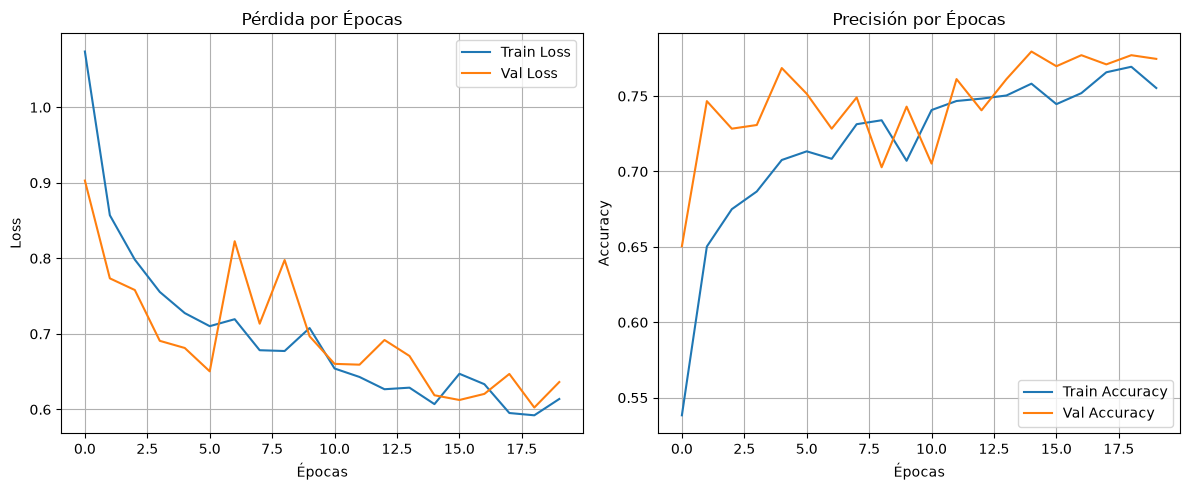

In [36]:
plt.figure(figsize=(12, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title("Pérdida por Épocas")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(val_acc_list, label='Val Accuracy')
plt.title("Precisión por Épocas")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Evaluación en el conjunto de test

Se evalúa el modelo entrenado sobre el conjunto de test, que no fue utilizado ni en el entrenamiento ni en la validación, y se calcula el reporte de clasificación (precision, recall y f1-score) por clase para medir qué tan bien generaliza a datos completamente nuevos.

In [37]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

test_accuracy = (all_preds == all_targets).mean()
print(f"Accuracy en test: {test_accuracy:.4f}\n")

reporte = classification_report(all_targets, all_preds, target_names=dataset_train_full.classes, digits=3)
print(reporte)

Accuracy en test: 0.7485

              precision    recall  f1-score   support

       jerry      0.799     0.733     0.765       195
         tom      0.793     0.749     0.770       271
 tom_jerry_0      0.705     0.835     0.765       243
 tom_jerry_1      0.670     0.588     0.626       114

    accuracy                          0.748       823
   macro avg      0.742     0.726     0.731       823
weighted avg      0.751     0.748     0.747       823



## Predicción en imágenes nuevas

Se seleccionan aleatoriamente algunas imágenes del set de test y se muestran junto a su clase real y la clase predicha por el modelo, con el porcentaje de confianza asociado, como validación cualitativa final.

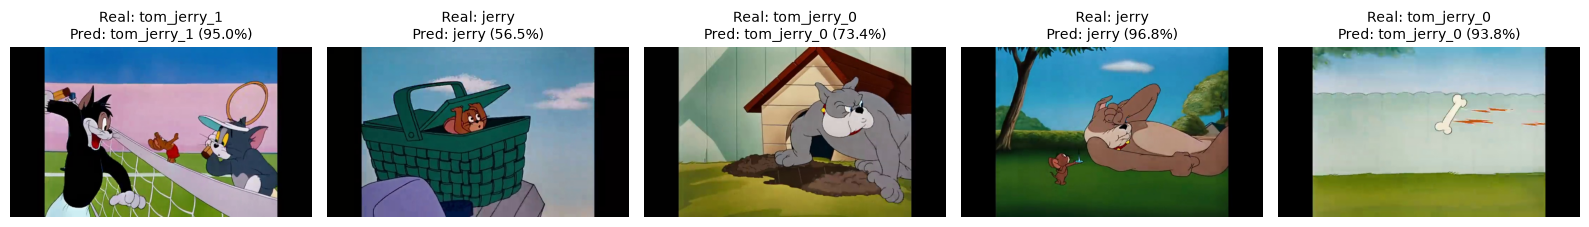

In [38]:
import random
from torch.nn import Softmax

random.seed(10)
muestra_indices = random.sample(test_indices, k=5)

fig, axes = plt.subplots(1, 5, figsize=(16, 10))

for ax, idx in zip(axes, muestra_indices):
    img_path, label_real = dataset_eval_full.samples[idx]
    img = Image.open(img_path).convert('RGB')

    img_transformed = transformaciones_eval(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        y_prob = model(img_transformed)
    y_prob = Softmax(dim=1)(y_prob).cpu().numpy()[0]

    clase_predicha = clases_nombres[y_prob.argmax()]
    confianza = y_prob.max() * 100

    ax.imshow(img)
    ax.set_title(f"Real: {clases_nombres[label_real]}\nPred: {clase_predicha} ({confianza:.1f}%)", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

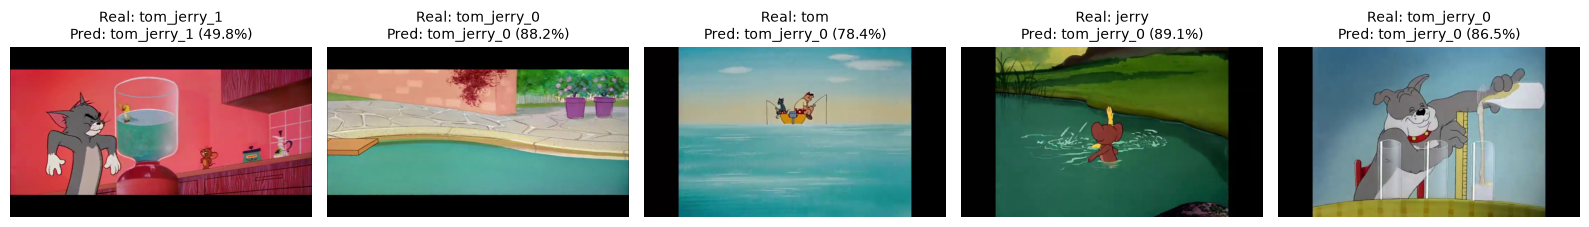

In [39]:
random.seed(3)
muestra_indices = random.sample(test_indices, k=5)

fig, axes = plt.subplots(1, 5, figsize=(16, 10))

for ax, idx in zip(axes, muestra_indices):
    img_path, label_real = dataset_eval_full.samples[idx]
    img = Image.open(img_path).convert('RGB')

    img_transformed = transformaciones_eval(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        y_prob = model(img_transformed)
    y_prob = Softmax(dim=1)(y_prob).cpu().numpy()[0]

    clase_predicha = clases_nombres[y_prob.argmax()]
    confianza = y_prob.max() * 100

    ax.imshow(img)
    ax.set_title(f"Real: {clases_nombres[label_real]}\nPred: {clase_predicha} ({confianza:.1f}%)", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()